<a href="https://colab.research.google.com/github/deadex-ng/arena/blob/main/chapter1_transformer_interp/exercises/part1_transformer_from_scratch/ViT_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn

In [14]:
transformation_operation = transforms.Compose([transforms.ToTensor()])

In [15]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform = transformation_operation)
val_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform= transformation_operation)

In [16]:
num_classes = 10
batch_size = 64
num_channels = 1
img_size = 28
patch_size = 7
num_patches = (img_size // patch_size) **2
embedding_dim = 64
attention_heads = 4
transformer_blocks = 4
mlp_hidden_nodes = 128
learning_rate = 0.001
epochs = 5

In [17]:
# Define dataset batches
train_loader = dataloader.DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
val_loader = dataloader.DataLoader(val_dataset, batch_size = batch_size, shuffle=True)


In [18]:
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size=patch_size, stride = patch_size)

  def forward(self, x):
    x = self.patch_embed(x)
    x = x.flatten(2)
    x = x.transpose(1,2)

    return x


In [19]:
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.layer_norm2 = nn.LayerNorm(embedding_dim)
    self.multihead_attention = nn.MultiheadAttention(embedding_dim, attention_heads, batch_first=True)
    self.mlp = nn.Sequential(
        nn.Linear(embedding_dim, mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes, embedding_dim)
    )
  def forward(self,x):
    residual1 = x
    x = self.layer_norm1(x)
    x = self.multihead_attention(x, x, x)[0]
    x = x + residual1

    residual2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x)
    x = x + residual2

    return x


In [20]:
class MLP_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.mlp_head = nn.Linear(embedding_dim, num_classes)

  def forward(self, x):
    x = self.layer_norm1(x)
    x = self.mlp_head(x)

    return x

In [21]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1,1,embedding_dim))
    self.position_embedding = nn.Parameter(torch.randn(1,num_patches+1, embedding_dim))
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
    self.mlp_head = MLP_head()

  def forward(self,x):
     x = self.patch_embedding(x)
     B = x.size(0)
     class_tokens = self.cls_token.expand(B, -1, -1)
     x = torch.cat((class_tokens,x), dim=1)
     x = x + self.position_embedding
     x = self.transformer_blocks(x)
     x = x [:,0]
     x = self.mlp_head(x)

     return x

In [22]:
device = torch.device('cude' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [23]:
for epoch in range(epochs):
  model.train()
  total_loss = 0
  correct_epoch = 0
  total_epoch = 0
  print(f"\nEpoch {epoch+1}")
  for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    preds = outputs.argmax(dim=1)
    correct = (preds == labels).sum().item()
    accuracy = 100.0 * correct / labels.size(0)

    correct_epoch += correct
    total_epoch += labels.size(0)

    if batch_idx % 100 == 0:
      print(f" Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

  epoch_acc = 100.0 * correct_epoch / total_epoch
  print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")






Epoch 1
 Batch   1: Loss = 2.4231, Accuracy = 14.06%
 Batch 101: Loss = 0.5468, Accuracy = 85.94%
 Batch 201: Loss = 0.2876, Accuracy = 90.62%
 Batch 301: Loss = 0.1692, Accuracy = 92.19%
 Batch 401: Loss = 0.2881, Accuracy = 87.50%
 Batch 501: Loss = 0.2576, Accuracy = 92.19%
 Batch 601: Loss = 0.1557, Accuracy = 95.31%
 Batch 701: Loss = 0.0717, Accuracy = 98.44%
 Batch 801: Loss = 0.2407, Accuracy = 93.75%
 Batch 901: Loss = 0.1405, Accuracy = 96.88%
==> Epoch 1 Summary: Total Loss = 332.9301, Accuracy = 89.06%

Epoch 2
 Batch   1: Loss = 0.2347, Accuracy = 93.75%
 Batch 101: Loss = 0.2029, Accuracy = 90.62%
 Batch 201: Loss = 0.1524, Accuracy = 95.31%
 Batch 301: Loss = 0.1960, Accuracy = 92.19%
 Batch 401: Loss = 0.1405, Accuracy = 93.75%
 Batch 501: Loss = 0.0511, Accuracy = 98.44%
 Batch 601: Loss = 0.1246, Accuracy = 96.88%
 Batch 701: Loss = 0.1619, Accuracy = 93.75%
 Batch 801: Loss = 0.0828, Accuracy = 96.88%
 Batch 901: Loss = 0.2189, Accuracy = 95.31%
==> Epoch 2 Summary:

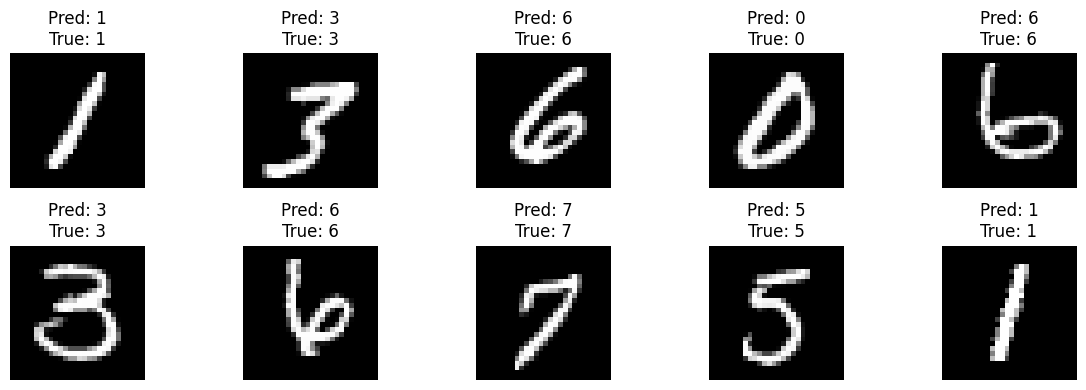

In [24]:
import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
  outputs = model(images)
  preds = outputs.argmax(dim=1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

# Plot first 10 images
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(images[i].squeeze(), cmap='gray')
  plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
  plt.axis('off')
plt.tight_layout()
plt.show()

In [25]:
data_point, label = next(iter(train_loader))
print("Shape of data point: ", data_point.shape)
patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size=patch_size, stride = patch_size)
patch_embed_output = patch_embed(data_point)
print(patch_embed_output.shape)
patch_embed_output_flatten = patch_embed_output.flatten(2)
print(patch_embed_output_flatten.shape)
patch_embed_output_flatten_transpose_output = patch_embed_output_flatten.transpose(1,2)
print(patch_embed_output_flatten_transpose_output.shape)

Shape of data point:  torch.Size([64, 1, 28, 28])
torch.Size([64, 64, 4, 4])
torch.Size([64, 64, 16])
torch.Size([64, 16, 64])
